# Lidar–VectorNav Sync Workbench

This notebook starts the implementation of per-window timing-offset estimation for lidar vertical stares against continuous VectorNav `VelNED2`.

The initial implementation covers:

- project setup and shared imports
- cached lidar chunk/file bookkeeping
- periodic beam buffers and single-file reads
- chunk extraction with the existing `fit_offset` prior
- mdv-based sync signal construction using the `1.03` intensity threshold
- FFT bandpass filtering, analytic-envelope construction, and FFT cross-correlation
- one-window diagnostics for coarse and fine timing estimates

Later cells can extend this to multi-window continuity priors, jump detection, and production integration.

In [1]:
# preamble
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Printf
using Statistics
using PyPlot
using NCDatasets

includet("./lidar_vn_sync.jl")
using .LidarVNSync

ctx = LidarVNSync.setup_sync_context()
Env = ctx.Env
Vn = ctx.Vn
UV = ctx.UV
beams = ctx.beams
icvn = ctx.icvn
nz = ctx.nz

  Activating project at `~/Projects/lidar/ASTRAL2024`


80

In [2]:
# notebook workflow functions

function process_lidar_vn_data(; mode=:test, test_ic=175:190, ntop=nz)
    ic_list = mode == :all ? collect(icvn) : collect(test_ic)
    # UV is passed through the shared reader for compatibility and later motion correction.
    # The sync offsets computed here are fit only from mdv and vn2.
    result = LidarVNSync.process_sync_data(
        beams,
        Env,
        Vn,
        UV,
        ic_list;
        ntop=ntop,
    )
    return result
end

function save_sync_data_netcdf(result; nc_out=joinpath("epsilon_data", "vn_sync_offsets.nc"))
    return LidarVNSync.save_sync_netcdf(result; nc_out=nc_out)
end

function run_sync_diagnostics(result; mode=:test, single_ic=nothing, ntop=nz)
    fig_offsets = LidarVNSync.diagnostic_offsets(result)

    fig_single = nothing
    if mode == :test
        ic = isnothing(single_ic) ? result.seq_ic[1] : single_ic
        single = LidarVNSync.diagnostic_single_window(beams, Env, Vn, UV, ic; ntop=ntop)
        fig_single = single.fig
    end

    return (; fig_offsets, fig_single)
end

read_synced_motion_data(nc_path=joinpath("epsilon_data", "vn_sync_offsets.nc")) =
    LidarVNSync.read_synced_motion(nc_path)

motion_correct_stare(dopplervel, nc_path=joinpath("epsilon_data", "vn_sync_offsets.nc"); record_inds=:) =
    LidarVNSync.read_and_motion_correct_stare(dopplervel, nc_path; record_inds=record_inds)

motion_correct_stare (generic function with 2 methods)

In [ ]:
# TEST: Chunks 200:500 offset sweep + example plots at target offsets 0, 2, 5, 10 s.
# This cell is intentionally repeatable and user-driven.
# Set RUN_TEST = true to execute, or keep false to edit safely first.

#=
refactor:
 - write the test inside a function.
 - parameters can be defined in lexical scope of the function
 - variables can be defined as function arguments; the first argument is whether to run the test.
=#

RUN_TEST = true

if !RUN_TEST
    println("Cell prepared. Set RUN_TEST = true when you want to execute.")
else

    test_chunks = 200:500
    targets_s = [0.0, 2.0, 5.0, 10.0]

    sync_result_200_500 = process_lidar_vn_data(; mode=:test, test_ic=test_chunks, ntop=nz)

    offset_s = Float64.(sync_result_200_500.seq_final_native)
    valid = isfinite.(offset_s) .& (offset_s .!= LidarVNSync.OFFSET_SENTINEL_S)

    println("chunk,offset_s")
    for (ic, off) in zip(sync_result_200_500.seq_ic, offset_s)
        println("$(ic),$(off)")
    end

    println("\nSummary")
    println("valid chunks: $(count(valid)) / $(length(valid))")
    if any(valid)
        vo = offset_s[valid]
        println("min/median/max offset_s: $(minimum(vo)) / $(median(vo)) / $(maximum(vo))")
    end

    idx_valid = findall(valid)
    isempty(idx_valid) && error("No valid offsets found for chunks 200:500")

    ic_valid = sync_result_200_500.seq_ic[idx_valid]
    off_valid = offset_s[idx_valid]
    pick = [argmin(abs.(off_valid .- t)) for t in targets_s]
    example_ic = ic_valid[pick]
    example_shift_s = off_valid[pick]

    println("\nExample picks (target_s, chunk, actual_s)")
    for i in eachindex(targets_s)
        println((targets_s[i], example_ic[i], example_shift_s[i]))
    end

    # Build per-window time-series comparison plots.
    state = LidarVNSync.init_stream_state()
    fig, axs = subplots(length(targets_s), 1, figsize=(15, 3.2 * length(targets_s)), sharex=false)
    length(targets_s) == 1 && (axs = [axs])

    for i in eachindex(targets_s)
        ic = example_ic[i]
        t_target = targets_s[i]
        t_shift = example_shift_s[i]

        win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=nz)
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        vn2_sync = LidarVNSync.shift_signal_linear(win.vn2_xcorr, t_shift; dt=dt1)

        mdv_bp = LidarVNSync.fft_bandpass(win.mdv; dt=dt1)
        vn2_bp = LidarVNSync.fft_bandpass(vn2_sync; dt=dt1)
        mdv_env = LidarVNSync.analytic_envelope_fft(mdv_bp)
        vn2_env = LidarVNSync.analytic_envelope_fft(vn2_bp)

        finite_env = isfinite.(mdv_env) .& isfinite.(vn2_env)
        env_scale = any(finite_env) ? maximum(abs, vcat(mdv_env[finite_env], vn2_env[finite_env])) : 1.0
        env_scale == 0 && (env_scale = 1.0)
        mdv_env_n = mdv_env ./ env_scale
        vn2_env_n = vn2_env ./ env_scale

        ax = axs[i]
        ax.plot(win.stare_dt, win.mdv, color="#1f77b4", linewidth=1.0, label="mdv")
        ax.plot(win.stare_dt, vn2_sync, color="#d62728", linewidth=1.0, alpha=0.9, label="vn2 shifted")
        ax.plot(win.stare_dt, mdv_env_n, color="#1f77b4", linestyle="--", linewidth=1.0, alpha=0.9, label="mdv env (norm)")
        ax.plot(win.stare_dt, vn2_env_n, color="#d62728", linestyle="--", linewidth=1.0, alpha=0.9, label="vn2 env shifted (norm)")
        ax.grid(true, alpha=0.3)
        ax.set_ylabel("signal")
        ax.set_title("target=$(round(t_target, digits=1)) s, chunk=$(ic), actual=$(round(t_shift, digits=3)) s")

        if i == 1
            ax.legend(loc="upper right", ncol=2, fontsize=8)
        end
        if i == length(targets_s)
            ax.set_xlabel("time")
        end
    end

    tight_layout()
    fig
end

In [4]:
# 1) process test data and compute offsets
sync_result_test = process_lidar_vn_data(; mode=:test, test_ic=175:190, ntop=nz)

@printf("processed chunks: %d\n", length(sync_result_test.seq_ic))
@printf("20 Hz offsets (ms): %s\n", string(sync_result_test.seq_final_native_ms))
@printf("20 Hz jumps (ms):   %s\n", string(sync_result_test.seq_jump_20hz_ms))

processed chunks: 16
20 Hz offsets (ms): [-100, -100, -50, -100, -100, -150, -50, -50, 0, 50, 0, 0, 0, 0, 0, 50]
20 Hz jumps (ms):   [0, 0, 50, -50, 0, -50, 100, 0, 50, 50, -50, 0, 0, 0, 0, 50]


In [ ]:
# 2) save test result as NetCDF
# nc_out = save_sync_data_netcdf(sync_result_test; nc_out=joinpath("epsilon_data", "vn_sync_offsets.nc"))
# println("Saved: ", nc_out)

# # quick schema check
# run(`ncdump -h $nc_out`)

Saved: epsilon_data/vn_sync_offsets.nc
netcdf vn_sync_offsets {
dimensions:
	chunk = 16 ;
	record = 8535 ;
variables:
	int chunk_index(chunk) ;
	int chunk_n_records(chunk) ;
	int chunk_record_start_idx(chunk) ;
	int chunk_record_end_idx(chunk) ;
	int64 chunk_start_epoch_ms(chunk) ;
		chunk_start_epoch_ms:long_name = "chunk start time in epoch milliseconds since 1970-01-01" ;
	int64 chunk_end_epoch_ms(chunk) ;
		chunk_end_epoch_ms:long_name = "chunk end time in epoch milliseconds since 1970-01-01" ;
	int64 offset_20hz_ms(chunk) ;
		offset_20hz_ms:units = "milliseconds" ;
		offset_20hz_ms:long_name = "final synchronization offset from 20 Hz native refinement" ;
	int64 jump_20hz_ms(chunk) ;
		jump_20hz_ms:units = "milliseconds" ;
		jump_20hz_ms:long_name = "chunk-to-chunk jump in 20 Hz native offset (current minus previous)" ;
	int64 time(record) ;
		time:units = "milliseconds since 2024-04-29T00:00:00 UTC" ;
		time:calendar = "standard" ;
		time:standard_name = "time" ;
		time:axis = "T"

Process(`ncdump -h epsilon_data/vn_sync_offsets.nc`, ProcessExited(0))

dopplervel   size=(537, 80)      missing= 24960 finite= 18000 nan=     0
intensity    size=(537, 80)      missing=     0 finite= 42960 nan=     0
Ur           size=(537, 80)      missing=     0 finite= 42960 nan=     0
Vr           size=(537, 80)      missing=     0 finite= 42960 nan=     0
clock prior applied: 149717 milliseconds
coarse offset after iterative envelope passes = 0.000 s
fine residual after coarse shift = -1.020 s
final offset (1 Hz stage) = -1.020 s
final offset (20 Hz raw) = -0.100 s
final offset (20 Hz native step) = -0.100 s [step=0.050]


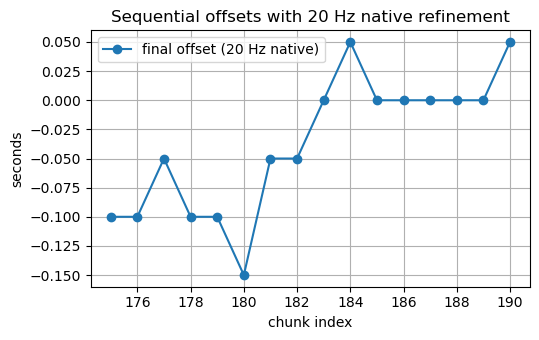

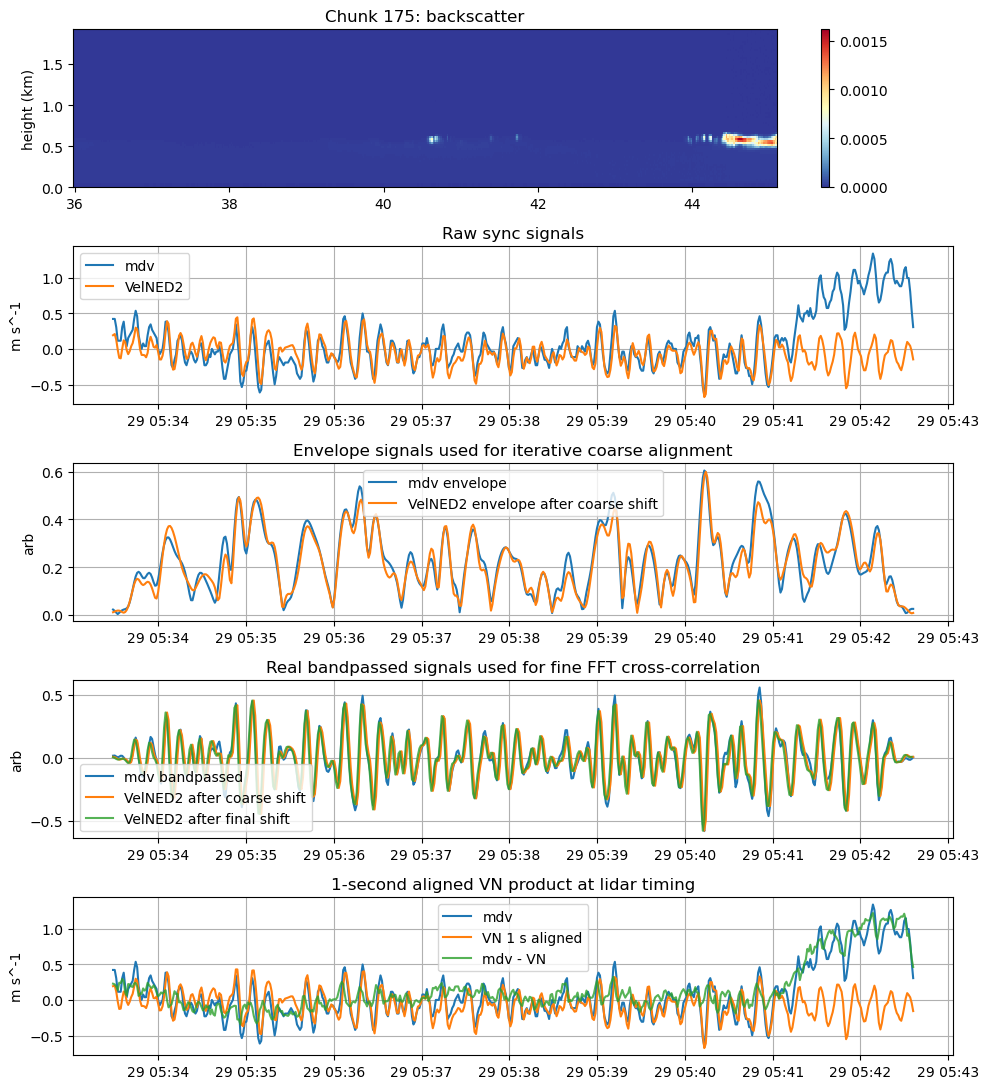

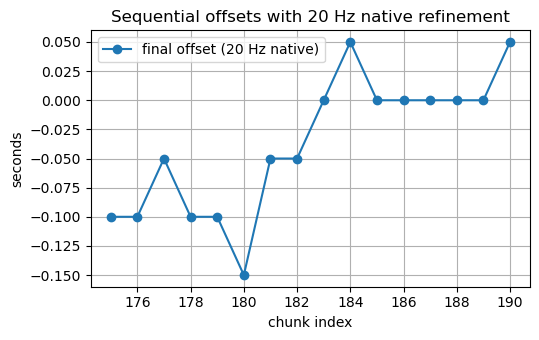

In [8]:
# 3) run diagnostics
# mode=:test shows both sequential offsets and one single-window diagnostic
diag_test = run_sync_diagnostics(sync_result_test; mode=:test, ntop=nz)

diag_test.fig_offsets
# diag_test.fig_single

Schema verified for test run: (:seq_results, :seq_ref20, :seq_ic, :seq_prior, :seq_coarse, :seq_final, :seq_final_native, :seq_final_native_ms, :seq_jump_20hz_ms, :seq_fine, :seq_jump_candidate, :seq_jump_accepted, :chunk_lens, :chunk_record_starts, :chunk_record_ends, :nrec)
Uncomment below to run full production processing with the same schema.
Saved full-record output: epsilon_data/vn_sync_offsets_all.nc


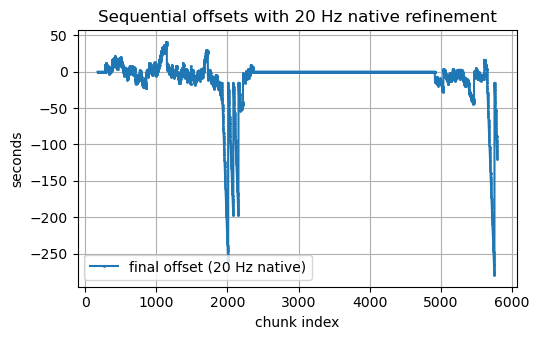

In [17]:
# Process VN offsets for the full lidar record
expected_schema = (
    :seq_results,
    :seq_ref20,
    :seq_ic,
    :seq_prior,
    :seq_coarse,
    :seq_final,
    :seq_final_native,
    :seq_final_native_ms,
    :seq_jump_20hz_ms,
    :seq_fine,
    :seq_jump_candidate,
    :seq_jump_accepted,
    :chunk_lens,
    :chunk_record_starts,
    :chunk_record_ends,
    :nrec,
)

@assert propertynames(sync_result_test) == expected_schema
println("Schema verified for test run: ", expected_schema)
println("Uncomment below to run full production processing with the same schema.")

# sync_result_all = process_lidar_vn_data(; mode=:all, ntop=nz) # takes ~ 2h
# @assert propertynames(sync_result_all) == expected_schema
# nc_out_all = save_sync_data_netcdf(sync_result_all; nc_out=joinpath("epsilon_data", "vn_sync_offsets_all.nc"))
diag_all = run_sync_diagnostics(sync_result_all; mode=:all, ntop=nz)
println("Saved full-record output: ", nc_out_all)

Using offsets file: epsilon_data/vn_sync_offsets_all.nc
Selected lag examples (target_s, ic, actual_s, abs_error_s):
(0.0, 183, 0.0, 0.0)
(-10.0, 601, -10.0, 0.0)
(-30.0, 5400, -29.9, 0.10000000000000142)
(-60.0, 1937, -60.4, 0.3999999999999986)
(-120.0, 2052, -119.45, 0.5499999999999972)
(-180.0, 2075, -179.65, 0.3499999999999943)


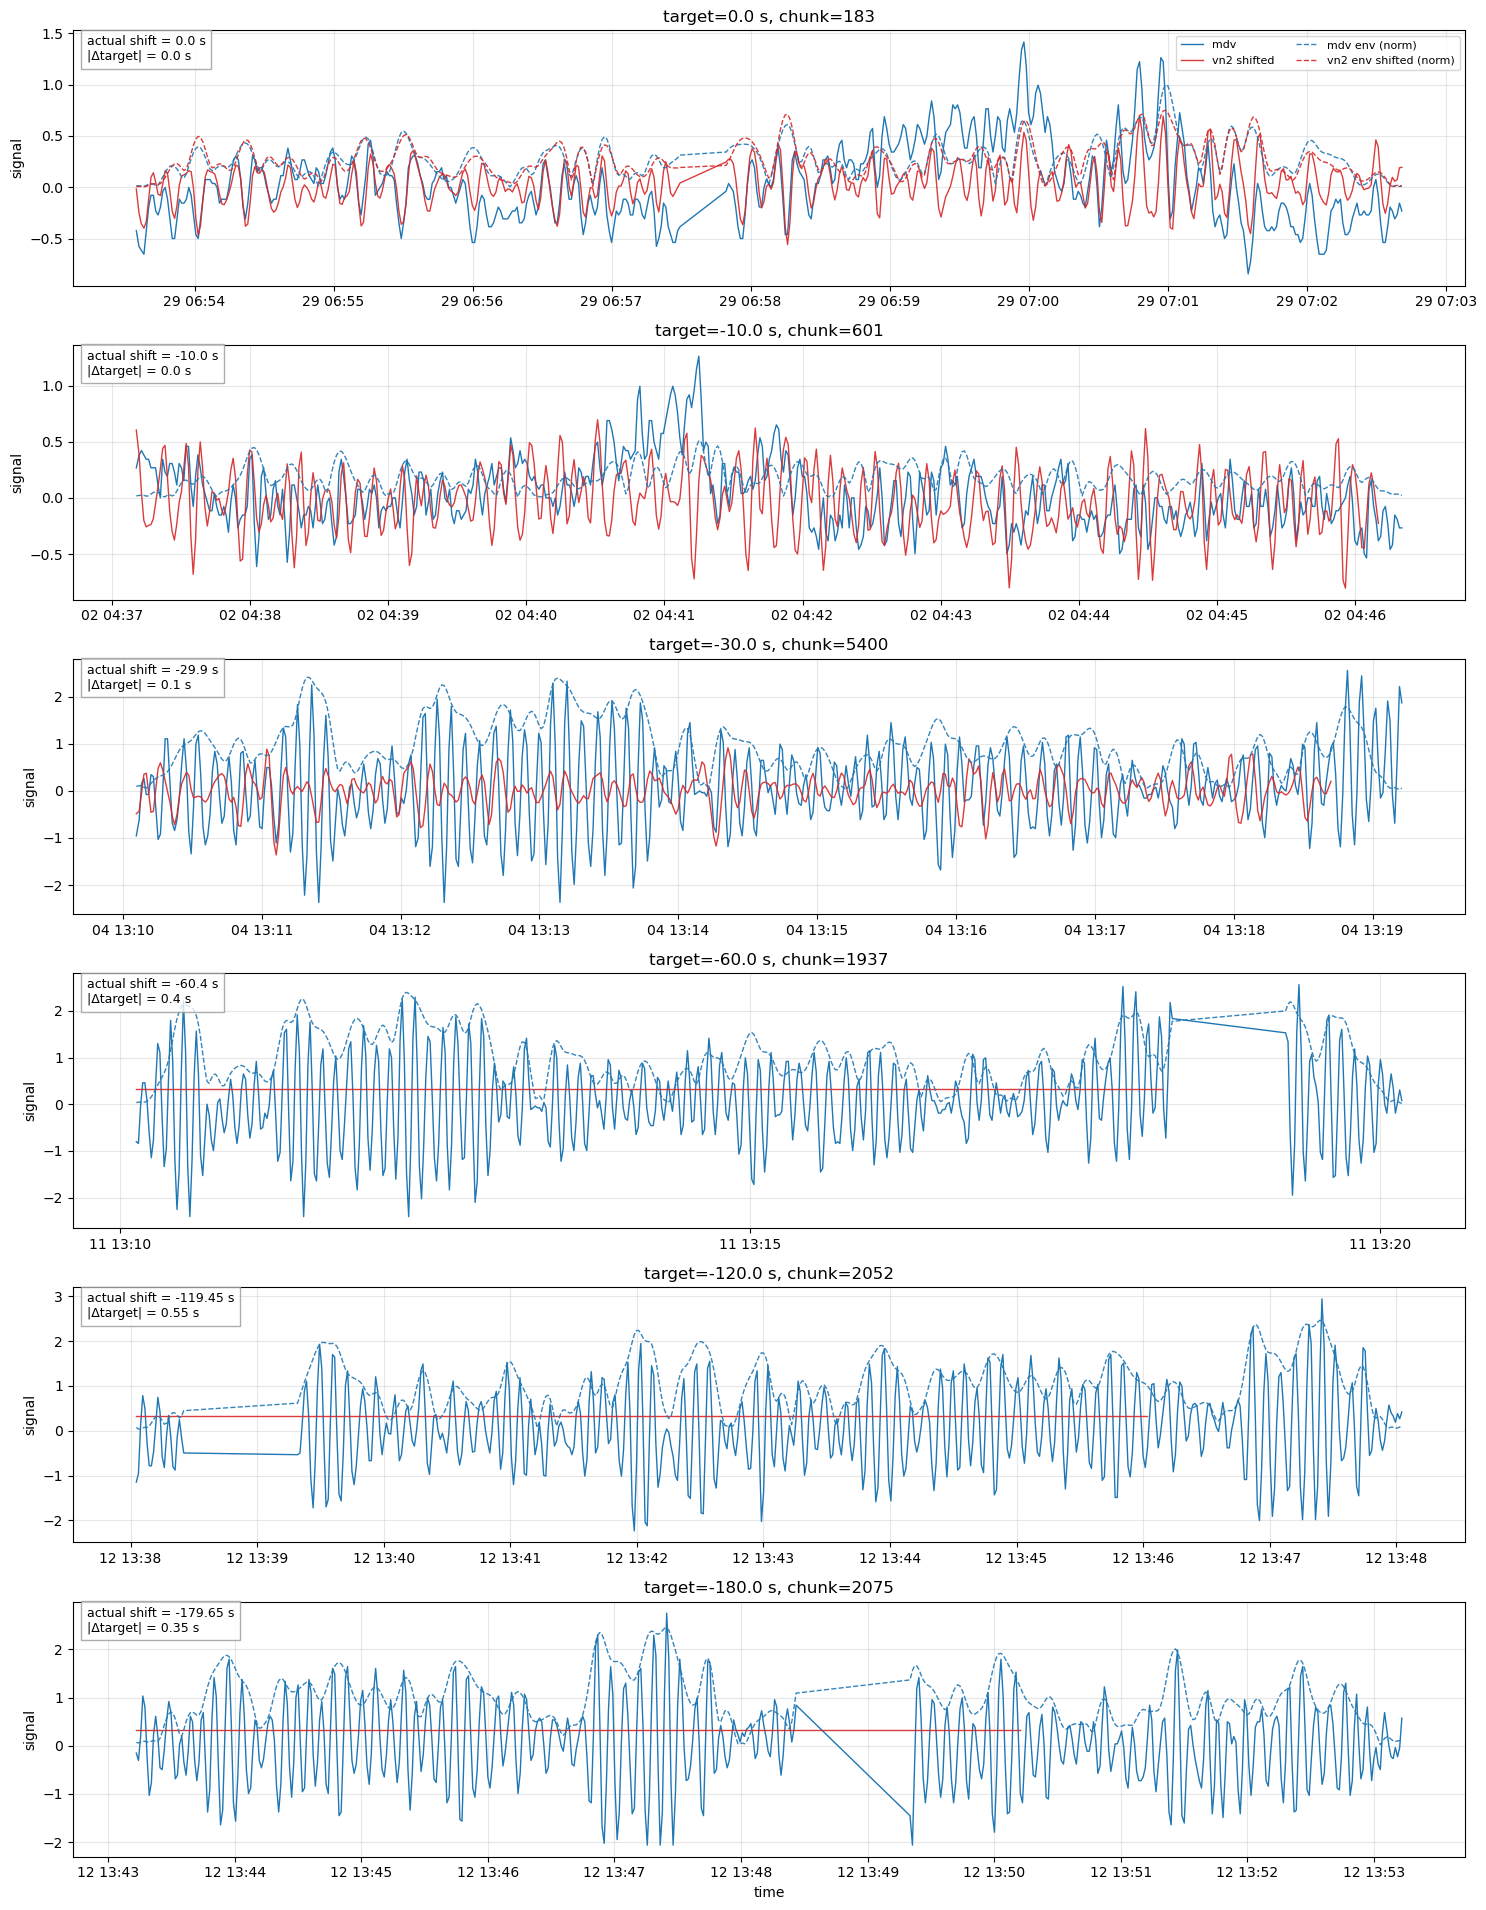

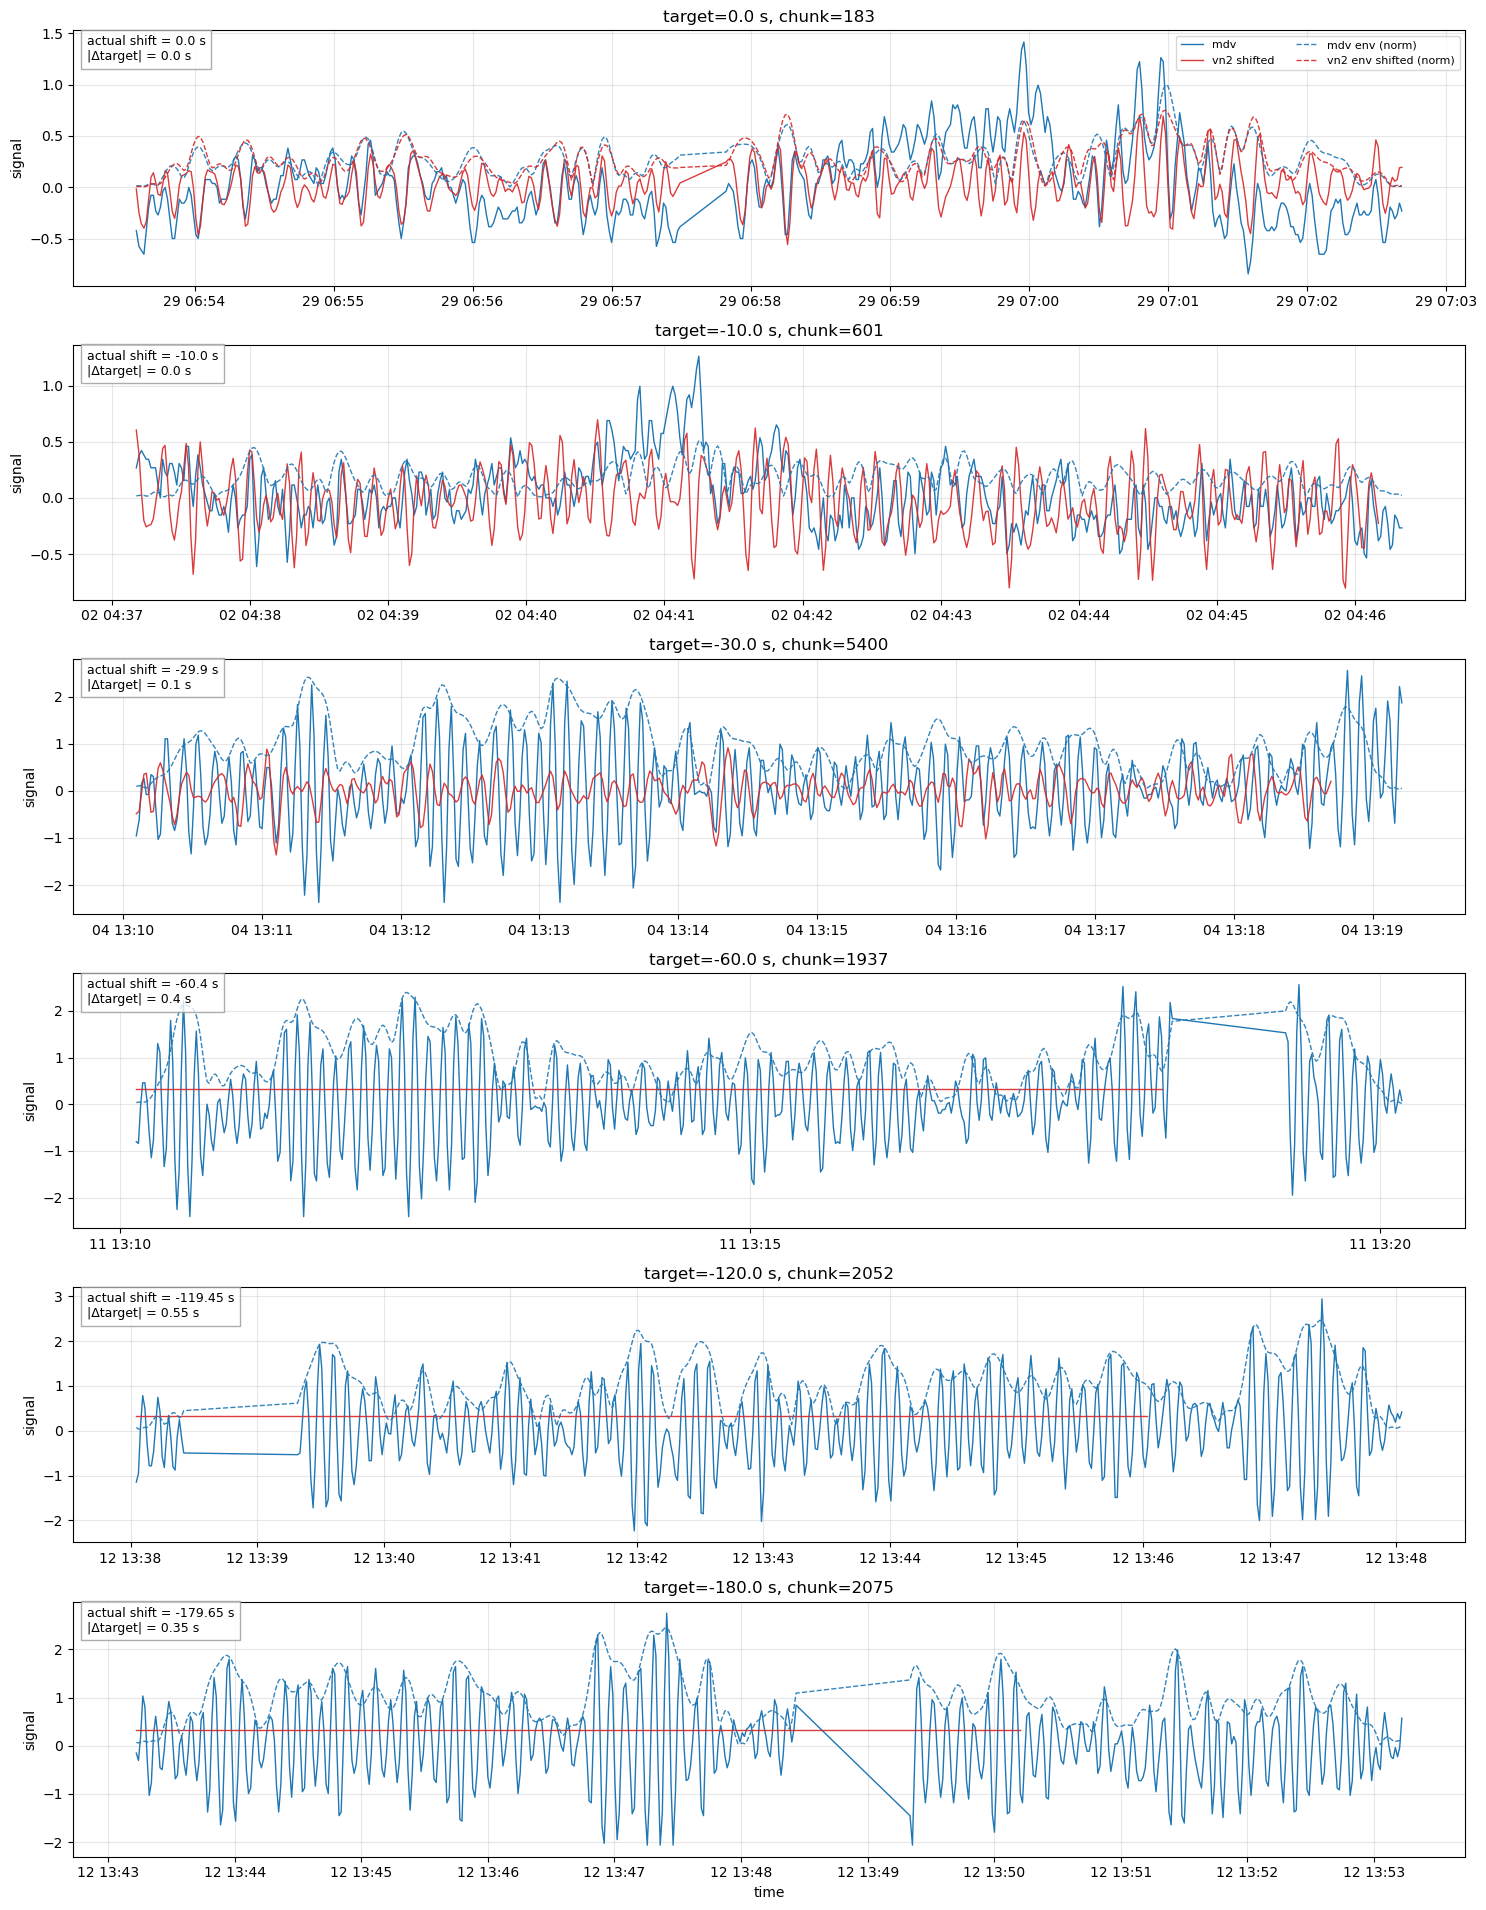

In [5]:
# 8) verify lag examples at target negative shifts (seconds)
# using NCDatasets
using Statistics
# using PyPlot

targets_s = [0.0, -10.0, -30.0, -60.0, -120.0, -180.0]
nc_candidates = [
    joinpath("epsilon_data", "vn_sync_offsets_all.nc"),
    joinpath("epsilon_data", "vn_sync_offsets.nc"),
]
nc_path = findfirst(isfile, nc_candidates)
isnothing(nc_path) && error("No vn_sync_offsets NetCDF found in epsilon_data/.")
nc_path = nc_candidates[nc_path]
println("Using offsets file: ", nc_path)

ds = NCDataset(nc_path, "r")
chunk_idx = Int.(ds["chunk_index"][:])
offset_ms = Float64.(ds["offset_20hz_ms"][:])
close(ds)

valid = isfinite.(offset_ms) .& (offset_ms .!= -9_999_000)
chunk_idx = chunk_idx[valid]
offset_s = offset_ms[valid] ./ 1000

pick = [argmin(abs.(offset_s .- t)) for t in targets_s]
example_ic = chunk_idx[pick]
example_shift_s = offset_s[pick]
example_abs_err_s = abs.(example_shift_s .- targets_s)

println("Selected lag examples (target_s, ic, actual_s, abs_error_s):")
for i in eachindex(targets_s)
    println((targets_s[i], example_ic[i], example_shift_s[i], example_abs_err_s[i]))
end

# Build sync context and pull each selected chunk.
ctx = LidarVNSync.setup_sync_context()
Env = ctx.Env
Vn = ctx.Vn
UV = ctx.UV
beams = ctx.beams
state = LidarVNSync.init_stream_state()

fig, axs = subplots(length(targets_s), 1, figsize=(15, 3.2 * length(targets_s)), sharex=false)
length(targets_s) == 1 && (axs = [axs])

for i in eachindex(targets_s)
    ic = example_ic[i]
    t_target = targets_s[i]
    t_shift = example_shift_s[i]
    t_err = example_abs_err_s[i]

    win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=ctx.nz)
    dt1 = LidarVNSync.dt_seconds(win.stare_dt)
    (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

    # Shift VN by selected offset and compare against mdv in the same panel.
    vn2_sync = LidarVNSync.shift_signal_linear(win.vn2, t_shift; dt=dt1)

    mdv_bp = LidarVNSync.fft_bandpass(win.mdv; dt=dt1)
    vn2_bp = LidarVNSync.fft_bandpass(vn2_sync; dt=dt1)
    mdv_env = LidarVNSync.analytic_envelope_fft(mdv_bp)
    vn2_env = LidarVNSync.analytic_envelope_fft(vn2_bp)

    # Normalize envelopes so both time series and envelopes are readable on one axis.
    finite_env = isfinite.(mdv_env) .& isfinite.(vn2_env)
    env_scale = any(finite_env) ? maximum(abs, vcat(mdv_env[finite_env], vn2_env[finite_env])) : 1.0
    env_scale == 0 && (env_scale = 1.0)
    mdv_env_n = mdv_env ./ env_scale
    vn2_env_n = vn2_env ./ env_scale

    ax = axs[i]
    ax.plot(win.stare_dt, win.mdv, color="#1f77b4", linewidth=1.0, label="mdv")
    ax.plot(win.stare_dt, vn2_sync, color="#d62728", linewidth=1.0, alpha=0.9, label="vn2 shifted")
    ax.plot(win.stare_dt, mdv_env_n, color="#1f77b4", linestyle="--", linewidth=1.0, alpha=0.9, label="mdv env (norm)")
    ax.plot(win.stare_dt, vn2_env_n, color="#d62728", linestyle="--", linewidth=1.0, alpha=0.9, label="vn2 env shifted (norm)")
    ax.grid(true, alpha=0.3)
    ax.set_ylabel("signal")
    ax.set_title("target=$(round(t_target, digits=1)) s, chunk=$(ic)")

    txt = "actual shift = $(round(t_shift, digits=3)) s\n|Δtarget| = $(round(t_err, digits=3)) s"
    ax.text(0.01, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
            bbox=Dict("facecolor"=>"white", "alpha"=>0.8, "edgecolor"=>"0.6"), fontsize=9)

    if i == 1
        ax.legend(loc="upper right", ncol=2, fontsize=8)
    end
    if i == length(targets_s)
        ax.set_xlabel("time")
    end
end

tight_layout()
fig

## Next Steps

The notebook is now organized around a module-based workflow:

- Cell 2: preamble and context setup from `lidar_vn_sync.jl`
- Cell 3: workflow wrapper functions
- Cell 4: process test interval and compute 20 Hz offsets/jumps
- Cell 5: save NetCDF output
- Cell 6: run diagnostics
- Cell 7: full-record processing template

Planned follow-up:

- run the full-record cell and save `vn_sync_offsets_all.nc`
- review jump behavior over the full record using 20 Hz millisecond jumps
- add any quality-control flags needed for production

### Offset Bookkeeping Note

The timing solution is now treated as:

- **prior offset**: the coarse offset already believed from previous chunks (or initialization)
- **refinement offset**: the new residual found in the current window
- **final offset**: `prior + refinement`

VectorNav window selection for refinement is anchored by the prior offset first, then the refinement is estimated and added.

If `lidar_clock_fast_by` is biased, correcting that term should improve the residual refinement behavior because the refinement stage is now explicitly layered on top of the prior rather than replacing it.